# 2장 4강: 이벤트 로그 기반 AARRR 퍼널 집계 및 시각화 — 실습문제

## 실습 목표

- 계정·구독·기능 사용 데이터를 연결하여 퍼널 단계 도달 기록을 만들 수 있다.
- `groupby()`와 `nunique()`로 단계별 고유 계정 수를 집계할 수 있다.
- 전 단계 대비 전환율과 최초 단계 대비 전체 전환율을 계산할 수 있다.
- 퍼널을 가로 막대그래프로 시각화하고 이탈 집중 구간을 찾을 수 있다.
- 수치에서 확인한 이탈 구간을 바탕으로 개선 가설과 검증 방법을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_accounts.csv`
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

Ravenstack은 구독형 B2B SaaS입니다. 이번 실습에서는 다음 네 단계를 누적 퍼널로 정의합니다.

| 단계 | 도달 조건 |
|---|---|
| Acquisition | 관찰 종료일보다 30일 이상 앞서 가입한 계정 |
| Activation | 가입 후 30일 이내 첫 구독을 시작한 계정 |
| Retention | Activation 계정 중 첫 구독 시작 30일 후에도 유효한 기능 사용 기록이 있는 계정 |
| Revenue | Retention 계정 중 첫 구독이 체험판이 아니고 `mrr_amount > 0`인 계정 |

> Ravenstack 데이터에는 다른 사용자를 추천한 행동을 뜻하는 Referral 이벤트가 없습니다. `referral_source`는 **현재 계정이 유입된 경로**이므로 Referral 행동으로 잘못 사용하지 않고, 이번 실습에서는 측정 가능한 Acquisition~Revenue 4단계만 분석합니다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 세 CSV 파일을 각각 `accounts`, `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치를 확인하세요.
5. 날짜 컬럼을 날짜형으로 변환하세요.
6. 계정별 가장 이른 구독을 `first_subscription`으로 만드세요.
7. 기능 사용 기록에 첫 구독 정보를 결합하고, 구독 시작 전 또는 종료 후 기록을 제외한 `valid_usage`를 만드세요.
8. 기능 사용 데이터의 마지막 날짜에서 30일을 뺀 날짜를 `observation_cutoff`으로 정하세요.

> 가입 직후 30일이 지나지 않은 계정은 Retention 도달 기회가 부족하므로 분석 대상에서 제외합니다.

In [4]:
# 실습 준비 코드를 작성하세요.
import pandas as pd
import matplotlib.pyplot as plt

accounts = pd.read_csv("./ravenstack_accounts.csv")
subscriptions = pd.read_csv("./ravenstack_subscriptions.csv")
feature_usage = pd.read_csv("./ravenstack_feature_usage.csv")

print(accounts.shape, subscriptions.shape, feature_usage.shape)
display(accounts.head())
display(subscriptions.head())
display(feature_usage.head())

print(accounts.isna().sum())
print(subscriptions.isna().sum())

accounts["signup_date"] = pd.to_datetime(accounts["signup_date"])
subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])
subscriptions["end_date"] = pd.to_datetime(subscriptions["end_date"])
feature_usage["usage_date"] = pd.to_datetime(feature_usage["usage_date"])

first_subscription = (
    subscriptions.sort_values("start_date")
    .groupby("account_id", as_index=False).first()
)
print(first_subscription.shape)  

usage_of_first_sub = feature_usage.merge(
    first_subscription[["account_id", "subscription_id", "start_date", "end_date"]],
    on="subscription_id", how="inner"
)
print(usage_of_first_sub.shape[0], "/", feature_usage.shape[0])  


valid_mask = (
    (usage_of_first_sub["usage_date"] >= usage_of_first_sub["start_date"]) &
    (usage_of_first_sub["end_date"].isna() | (usage_of_first_sub["usage_date"] <= usage_of_first_sub["end_date"]))
)
valid_usage = usage_of_first_sub[valid_mask].copy()
print(len(valid_usage))  


observation_cutoff = feature_usage["usage_date"].max() - pd.Timedelta(days=30)
print(feature_usage["usage_date"].max(), "→ observation_cutoff:", observation_cutoff)

(500, 10) (5000, 14) (25000, 8)


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


account_id         0
account_name       0
industry           0
country            0
signup_date        0
referral_source    0
plan_tier          0
seats              0
is_trial           0
churn_flag         0
dtype: int64
subscription_id         0
account_id              0
start_date              0
end_date             4514
plan_tier               0
seats                   0
mrr_amount              0
arr_amount              0
is_trial                0
upgrade_flag            0
downgrade_flag          0
churn_flag              0
billing_frequency       0
auto_renew_flag         0
dtype: int64
(500, 14)
2480 / 25000
788
2024-12-31 00:00:00 → observation_cutoff: 2024-12-01 00:00:00


---

## 필수 1. AARR 단계별 고유 계정 수와 전환율 계산하기

### 문제 1-1. 가입한 계정은 활성화·유지·유료 단계까지 얼마나 도달하는가?

#### 문제 해결 방향

각 단계의 조건을 만족하는 계정 ID를 만들고, 앞 단계에 도달한 계정만 다음 단계에 포함되도록 누적 조건을 적용하세요. 그다음 긴 형태의 `funnel_log`를 만들어 강의에서 배운 `groupby()`와 `nunique()`로 집계합니다.

#### 요구사항

1. `signup_date <= observation_cutoff`인 계정을 `funnel_base`로 만드세요.
2. Acquisition, Activation, Retention, Revenue 도달 여부를 불리언 컬럼으로 만드세요.
3. 단계별 도달 계정만 모아 `account_id`, `stage`로 구성된 `funnel_log`를 만드세요.
4. `groupby("stage")["account_id"].nunique()`로 고유 계정 수를 집계하세요.
5. `reindex()`를 사용해 `Acquisition → Activation → Retention → Revenue` 순서로 정렬하세요.
6. `calc_conversion_rates()` 함수를 작성하여 전 단계 대비 전환율과 전체 대비 전환율을 계산하세요.
7. 단계별 고유 계정 수와 두 전환율을 하나의 `funnel_summary`로 출력하세요.

#### 해석 질문

**Q1.** 이벤트 발생 횟수 대신 고유 계정 수를 사용하는 이유는 무엇인가요?  
**Q2.** 첫 단계의 전 단계 대비 전환율을 100%로 설정하는 이유는 무엇인가요?  
**Q3.** Retention 단계에 이전 단계 조건을 함께 적용해야 하는 이유는 무엇인가요?  
**Q4.** 전 단계 대비 전환율과 전체 대비 전환율은 무엇이 다른가요?

#### 제출 결과

- `funnel_base`와 `funnel_log`
- `calc_conversion_rates()` 함수
- `funnel_summary`
- Q1~Q4 답변

In [5]:
# 필수 1 코드를 작성하세요.
funnel_base = accounts[accounts["signup_date"] <= observation_cutoff].copy()

sub_cols = first_subscription[
    ["account_id", "subscription_id", "start_date", "end_date", "is_trial", "mrr_amount", "plan_tier"]
].rename(columns={
    "subscription_id": "first_subscription_id", "start_date": "first_sub_start",
    "end_date": "first_sub_end", "is_trial": "first_sub_is_trial",
    "mrr_amount": "first_sub_mrr", "plan_tier": "first_sub_plan_tier"
})
funnel_base = funnel_base.merge(sub_cols, on="account_id", how="left")
print("funnel_base 크기:", len(funnel_base), "/", len(accounts))


funnel_base["reached_acquisition"] = True

days_to_sub = (funnel_base["first_sub_start"] - funnel_base["signup_date"]).dt.days
funnel_base["reached_activation"] = (
    funnel_base["first_sub_start"].notna() & (days_to_sub >= 0) & (days_to_sub <= 30)
)

retention_cutoff_flags = (
    valid_usage.merge(funnel_base[["account_id", "first_sub_start"]], on="account_id", how="left")
    .assign(cutoff=lambda d: d["first_sub_start"] + pd.Timedelta(days=30))
    .query("usage_date >= cutoff")["account_id"].unique()
)
funnel_base["reached_retention"] = (
    funnel_base["reached_activation"] & funnel_base["account_id"].isin(retention_cutoff_flags)
)

funnel_base["reached_revenue"] = (
    funnel_base["reached_retention"]
    & (funnel_base["first_sub_is_trial"] == False)
    & (funnel_base["first_sub_mrr"] > 0)
)

stage_map = {"reached_acquisition": "Acquisition", "reached_activation": "Activation",
             "reached_retention": "Retention", "reached_revenue": "Revenue"}
funnel_log = pd.concat([
    funnel_base.loc[funnel_base[col], ["account_id"]].assign(stage=name)
    for col, name in stage_map.items()
], ignore_index=True)

order = ["Acquisition", "Activation", "Retention", "Revenue"]
stage_counts = funnel_log.groupby("stage")["account_id"].nunique().reindex(order)
print(stage_counts)

def calc_conversion_rates(counts):
    df = counts.to_frame("accounts")
    df["step_conversion"] = df["accounts"] / df["accounts"].shift(1)
    df.loc[df.index[0], "step_conversion"] = 1.0
    df["overall_conversion"] = df["accounts"] / df["accounts"].iloc[0]
    return df

funnel_summary = calc_conversion_rates(stage_counts)
funnel_summary["step_conversion"] = (funnel_summary["step_conversion"] * 100).round(2)
funnel_summary["overall_conversion"] = (funnel_summary["overall_conversion"] * 100).round(2)
display(funnel_summary)

funnel_base 크기: 483 / 500
stage
Acquisition    483
Activation     321
Retention      184
Revenue        155
Name: account_id, dtype: int64


,accounts,step_conversion,overall_conversion
stage,,,
Acquisition,483,100.00,100.00
Activation,321,66.46,66.46
Retention,184,57.32,38.10
Revenue,155,84.24,32.09


### 필수 1 답변 작성란

- **Q1.** 같은 계정이 이벤트를 여러 번 남겨도 도달 여부는 몇 명인지가 중요하므로, 이벤트 발생 횟수 대신 고유 계정 수를 사용해야 인원이 부풀려지지 않음
- **Q2.** 첫 단계는 비교할 이전 단계가 없으므로, 자기 자신 대비 100%로 두어 이후 단계들의 손실을 이 기준선 대비로 볼 수 있게 함
- **Q3.** Activation을 거치지 않은 계정은 애초에 Retention을 따질 대상이 아니므로 이전 단계 조건을 함께 적용해야 분모가 왜곡되지 않음
- **Q4.** 전 단계 대비 전환율은 바로 앞 단계 대비 손실, 전체 대비 전환율은 최초 대비 누적 손실을 보여줌. Revenue의 전 단계 대비는 84.24%로 양호해 보이지만 전체 대비는 32.09%로, Acquisition부터 보면 이미 3분의 2가 빠져나감.

---

## 필수 2. 퍼널 시각화와 이탈 구간 개선 가설 만들기

### 문제 2-1. 가장 먼저 개선해야 할 구간은 어디인가?

#### 요구사항

1. 필수 1의 `funnel_summary`를 사용하세요.
2. `barh()`로 단계별 고유 계정 수를 가로 막대그래프로 표시하세요.
3. 막대 옆에 `계정 수 (전 단계 대비 전환율)`을 표시하세요.
4. 첫 단계를 제외하고 전 단계 대비 전환율이 가장 낮은 단계를 찾으세요.
5. 해당 단계와 바로 이전 단계를 이용해 전환율이 가장 낮은 구간을 출력하세요.
6. 이탈 원인 가설 2개와 각 가설의 검증 방법을 제안하세요.

#### 해석 질문

**Q1.** 전 단계 대비 전환율이 가장 낮은 단계와 이탈 구간은 어디인가요?  
**Q2.** 퍼널 결과만으로 이탈의 원인을 확정할 수 있나요?  
**Q3.** 해당 구간을 개선하기 위해 어떤 데이터를 추가로 확인할 수 있나요?

#### 제출 결과

- 전환율을 표시한 퍼널 그래프
- 가장 낮은 전환 단계와 이탈 구간
- 개선 가설 2개와 검증 방법
- Q1~Q3 답변

In [7]:
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호(-)가 깨지는 것 방지

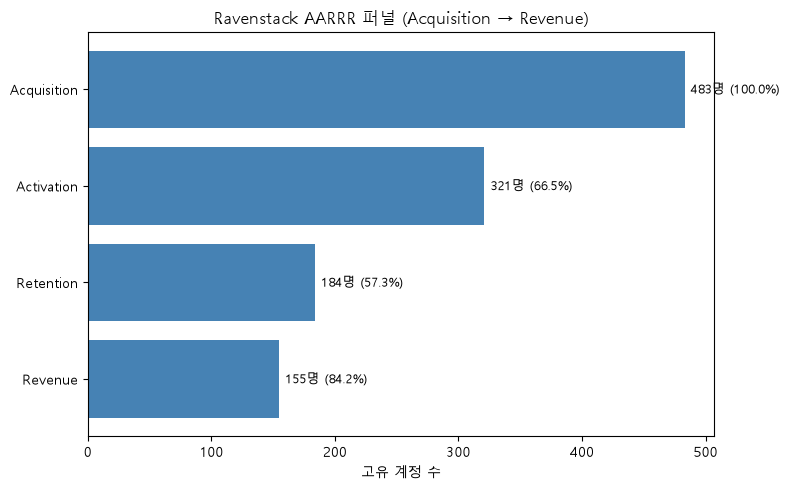

전환율이 가장 낮은 단계: Retention 57.32%
이탈 구간: Activation → Retention
이탈 계정 수: 137명 (이탈률 42.68%)


In [8]:
labels = funnel_summary.index.tolist()
counts = funnel_summary["accounts"].tolist()
convs = funnel_summary["step_conversion"].tolist()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(labels[::-1], counts[::-1], color="steelblue")
for bar, c, conv in zip(bars, counts[::-1], convs[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"{c}명 ({conv:.1f}%)", va="center", fontsize=9)
ax.set_xlabel("고유 계정 수")
ax.set_title("Ravenstack AARRR 퍼널 (Acquisition → Revenue)")
plt.tight_layout()
plt.show()

non_first = funnel_summary.iloc[1:]
worst_stage = non_first["step_conversion"].idxmin()
print("전환율이 가장 낮은 단계:", worst_stage, f"{non_first.loc[worst_stage, 'step_conversion']}%")

prev_stage = order[order.index(worst_stage) - 1]
prev_count = funnel_summary.loc[prev_stage, "accounts"]
curr_count = funnel_summary.loc[worst_stage, "accounts"]
print(f"이탈 구간: {prev_stage} → {worst_stage}")
print(f"이탈 계정 수: {prev_count - curr_count}명 (이탈률 {100 - non_first.loc[worst_stage, 'step_conversion']:.2f}%)")

### 필수 2 답변 작성란

- **Q1.** 전 단계 대비 전환율이 가장 낮은 단계는 Retention(57.32%)이며, 이탈 구간은 Activation → Retention
- **Q2.** 아니요. 퍼널 수치는 어디서 빠지는가만 보여줄 뿐 왜 빠지는가는 설명하지 않음.
- **Q3.** 개선 가설 2가지와 검증법: 온보딩 과정에서 핵심 기능을 충분히 안내받지 못했을 것이다 → 온보딩 완료 여부와 Retention 도달률 비교로 검증, 처음 접한 기능이 업무 흐름과 맞지 않았을 것이다 → Activation 시점에 처음 사용한 feature_name별 Retention 도달률 비교로 검증.

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 첫 구독 요금제별 퍼널 비교와 개선 가설 제안하기

#### 문제 설명

첫 구독의 plan_tier별로 Acquisition → Activation → Retention → Revenue 단계의 계정 수와 전환율을 비교하세요. 이탈이 집중된 구간을 찾고, 개선 가설과 검증 방법을 제안하세요.

> 필수 문제의 단계 정의와 집계·전환율 계산·시각화 절차를 그대로 활용합니다. Referral은 관련 행동 기록이 없어 분석에서 제외합니다.

#### 요구사항

1. 원시 계정·구독·기능 사용 데이터를 연결하여 funnel_base와 단계 도달 여부를 만드는 코드를 제출물에 포함하세요. 필수 문제에서 작성한 코드를 재사용해도 됩니다.
2. 첫 구독의 plan_tier별로 Acquisition, Activation, Retention, Revenue의 고유 계정 수를 집계하세요. 각 단계에는 이전 단계에 도달한 계정만 포함하세요.
3. 요금제별로 다음 값을 계산하여 plan_funnel을 만드세요.
- 구간 전환율 = 현재 단계 계정 수 ÷ 이전 단계 계정 수 × 100
- 구간 이탈률 = 100 − 구간 전환율
- 구간 이탈 계정 수 = 이전 단계 계정 수 − 현재 단계 계정 수
- 첫 단계는 비교할 이전 단계가 없으므로 구간 지표를 빈 값으로 두세요. 이전 단계 계정 수가 0이면 전환율·이탈률을 계산 불가로 표시하세요.
4. 요금제별로 단계별 고유 계정 수를 가로 막대그래프로 시각화하고, 각 단계의 구간 전환율을 함께 표시하세요.
5. 첫 단계를 제외하고 전환율이 가장 낮은 요금제·구간 조합을 찾으세요. 해당 구간의 전환율·이탈률·이탈 계정 수를 근거로 이탈 집중 구간을 설명하세요.
6. 요금제별 최종 Revenue 도달률을 계산하여 plan_summary로 출력하세요. 가장 높은 요금제와 낮은 요금제의 차이를 %p로 계산하세요.
- 최종 Revenue 도달률 = Revenue 계정 수 ÷ Acquisition 계정 수 × 100
7. 우선 점검할 구간에 대해 “어떤 원인 때문에 이탈하며, 어떤 변경을 하면 전환율이 개선될 것이다”라는 개선 가설을 한 가지 작성하세요.
8. 가설을 확인하기 위한 추가 데이터 2가지와 검증 방법을 설명하세요. 어떤 대상을 비교하고 어떤 지표로 개선 여부를 판단할지 포함하세요. 실제 실험이나 통계 검정은 수행하지 않아도 됩니다.

#### 해석 질문

Q1. 전환율이 가장 낮은 요금제와 구간은 무엇이며, 전환율·이탈률·이탈 계정 수는 얼마인가요?

Q2. 최종 Revenue 도달률이 가장 높은 요금제와 낮은 요금제는 무엇이며, 차이는 몇 %p인가요?

Q3. 우선 점검할 구간에 대한 개선 가설은 무엇이며, 어떤 데이터와 방법으로 검증할 수 있나요?

Q4. 요금제별 차이만으로 요금제가 이탈의 원인이라고 결론 내릴 수 있나요?

#### 제출 결과

- 원시 데이터 연결 및 단계 도달 여부 구성 코드
- plan_funnel: 단계별 계정 수·전환율·이탈률·이탈 계정 수
- 요금제별 퍼널 그래프
- 이탈 집중 구간과 수치 근거
- plan_summary: 최종 Revenue 도달률과 최고·최저 차이
- 개선 가설·추가 확인 데이터 2가지·검증 방법
- Q1~Q4 답변

,plan_tier,stage,accounts,step_conv_pct,step_drop_pct,step_drop_accounts
0,Basic,Acquisition,162,NaN,NaN,NaN
1,Basic,Activation,102,62.96,37.04,60.0
2,Basic,Retention,61,59.80,40.20,41.0
3,Basic,Revenue,49,80.33,19.67,12.0
4,Pro,Acquisition,160,NaN,NaN,NaN
5,Pro,Activation,102,63.75,36.25,58.0
6,Pro,Retention,59,57.84,42.16,43.0
7,Pro,Revenue,52,88.14,11.86,7.0
8,Enterprise,Acquisition,161,NaN,NaN,NaN
9,Enterprise,Activation,117,72.67,27.33,44.0


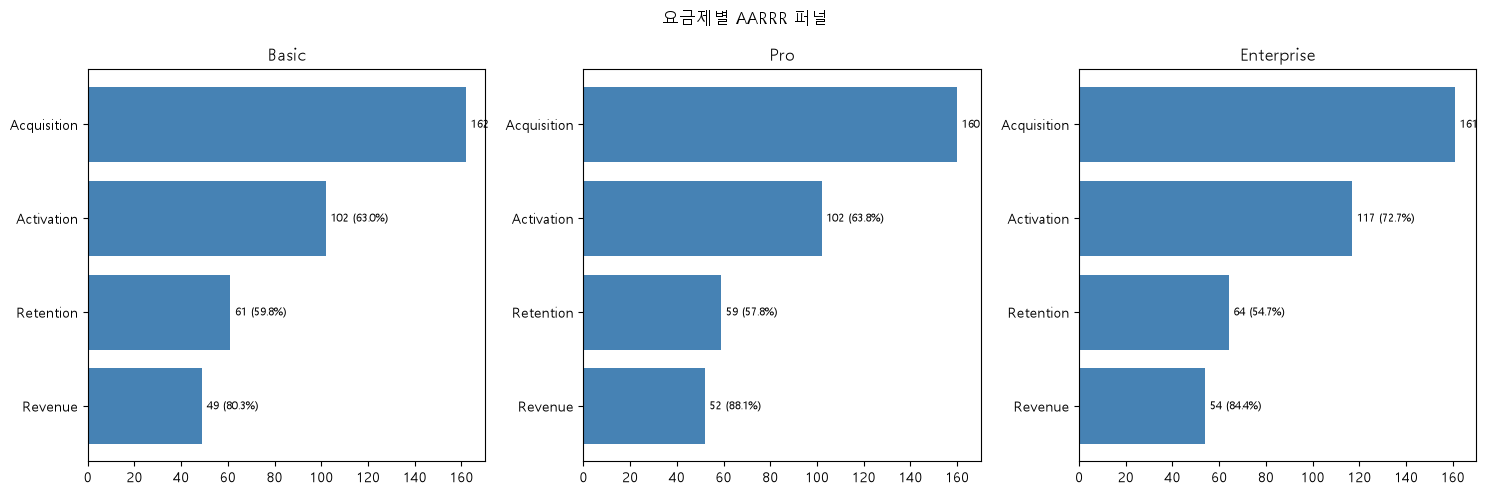

plan_tier             Enterprise
stage                  Retention
accounts                      64
step_conv_pct               54.7
step_drop_pct               45.3
step_drop_accounts          53.0
Name: 10, dtype: object


stage,Acquisition,Activation,Retention,Revenue,revenue_reach_rate_pct
plan_tier,,,,,
Basic,162,102,61,49,30.25
Enterprise,161,117,64,54,33.54
Pro,160,102,59,52,32.50


최고-최저 차이(%p): 3.29


In [9]:
# 과제 1 코드를 작성하세요.

cols_map = {"Acquisition": "reached_acquisition", "Activation": "reached_activation",
            "Retention": "reached_retention", "Revenue": "reached_revenue"}

rows = []
for plan in ["Basic", "Pro", "Enterprise"]:
    sub = funnel_base[funnel_base["first_sub_plan_tier"] == plan]
    stage_counts_plan = {stage: int(sub[cols_map[stage]].sum()) for stage in order}
    prev = None
    for i, stage in enumerate(order):
        c = stage_counts_plan[stage]
        if i == 0:
            step_conv = step_drop = drop_n = None
        else:
            step_conv = round(c / prev * 100, 2) if prev else None
            step_drop = round(100 - step_conv, 2) if step_conv is not None else None
            drop_n = prev - c if prev is not None else None
        rows.append({"plan_tier": plan, "stage": stage, "accounts": c,
                      "step_conv_pct": step_conv, "step_drop_pct": step_drop, "step_drop_accounts": drop_n})
        prev = c

plan_funnel = pd.DataFrame(rows)
display(plan_funnel)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)
for ax, plan in zip(axes, ["Basic", "Pro", "Enterprise"]):
    d = plan_funnel[plan_funnel["plan_tier"] == plan]
    bars = ax.barh(d["stage"][::-1], d["accounts"][::-1], color="steelblue")
    for bar, conv in zip(bars, d["step_conv_pct"][::-1]):
        label = f"{bar.get_width():.0f}" + (f" ({conv:.1f}%)" if pd.notna(conv) else "")
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, label, va="center", fontsize=8)
    ax.set_title(plan)
plt.suptitle("요금제별 AARRR 퍼널")
plt.tight_layout()
plt.show()

non_first_plan = plan_funnel[plan_funnel["stage"] != "Acquisition"]
worst_row = non_first_plan.loc[non_first_plan["step_conv_pct"].idxmin()]
print(worst_row)

plan_summary = plan_funnel.pivot(index="plan_tier", columns="stage", values="accounts")[order]
plan_summary["revenue_reach_rate_pct"] = (plan_summary["Revenue"] / plan_summary["Acquisition"] * 100).round(2)
display(plan_summary)
print("최고-최저 차이(%p):", round(plan_summary["revenue_reach_rate_pct"].max() - plan_summary["revenue_reach_rate_pct"].min(), 2))

### 과제 1 답변 작성란
- **Q1.** 전환율이 가장 낮은 조합은 Enterprise의 Activation→Retention 구간. 전환율 54.70%, 이탈률 45.30%, 이탈 계정 53명.
- **Q2.** 최종 Revenue 도달률이 가장 높은 요금제는 Enterprise, 가장 낮은 요금제는 Basic이고 차이는 3.29%p.
- **Q3.** 우선 점검 구간은 Enterprise의 Activation→Retention이며, 개선 가설은 초기 도입/온보딩 지연으로 재사용까지 이어지지 못한다. 온보딩 완료 시점, 초기 오류 발생 데이터로 검증할 수 있음.
- **Q4.** 아니요. 요금제 간 최종 Revenue 도달률 차이가 3.29%p로 크지 않고, 각 요금제 내부에서도 단계별 전환율 편차가 있어 요금제 자체보다 고객사 규모·온보딩 과정 등 다른 요인이 함께 작용했을 가능성을 고려해야 함.

---

## 실습 마무리

1. 이번 분석에서는 각 AARR 단계를 어떤 조건으로 정의했나요?
2. 단계별 고유 계정 수는 어떤 코드로 집계했나요?
3. 전 단계 대비 전환율과 전체 대비 전환율은 각각 무엇을 보여주나요?
4. 어느 구간에서 이탈이 가장 집중되었나요?
5. 퍼널 수치와 이탈 원인을 왜 구분해야 하나요?
6. Referral 단계를 이번 분석에서 제외한 이유는 무엇인가요?

1. Acquisition은 30일 이상 앞서 가입, Activation은 가입 후 30일 내 첫 구독, Retention은 첫 구독 30일 후에도 사용 기록 있음, Revenue는 체험판 아니고 MRR 있음으로 정의했다. 각 단계는 이전 단계를 통과한 계정만 포함되도록 누적 조건으로 만들었다.

2. 단계별 도달 여부를 불리언으로 만든 뒤 account_id, stage로 된 긴 형태 테이블(funnel_log)을 만들고 groupby("stage")["account_id"].nunique()로 집계했다.

3. 전 단계 대비 전환율은 바로 앞 단계에서 몇 %가 넘어왔는지(구간 손실), 전체 대비 전환율은 처음(Acquisition) 대비 지금까지 몇 %가 남았는지(누적 손실)를 보여준다. Revenue는 전 단계 대비로는 84%대로 괜찮아 보이지만 전체 대비로는 32%밖에 안 돼서, 두 지표가 주는 인상이 다르다.

4. Activation → Retention 구간에서 이탈이 가장 컸다(전환율 57.32%, 이탈 137명). 요금제별로는 Enterprise가 이 구간에서 가장 낮았다(54.70%).

5. 퍼널 수치는 어디서 빠지는지만 보여줄 뿐 왜 빠지는지는 알려주지 않기 때문이다. 원인을 확인하려면 온보딩 데이터나 기능 사용 로그 같은 추가 정보가 필요하다.

6. referral_source는 고객이 어디서 유입됐는지를 나타낼 뿐, 실제로 다른 고객을 추천했다는 행동 기록이 아니기 때문에 Referral 단계는 이번 분석에서 뺐다.